Code Training

In [2]:
import torch
import os
from matplotlib import pyplot as plt
import numpy as np
import cv2
import uuid
import os
import time

In [10]:
!git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...


In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
NVIDIA GeForce RTX 5070 Laptop GPU


In [3]:
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

Using cache found in C:\Users\Tanmay Arya/.cache\torch\hub\ultralytics_yolov5_master
YOLOv5  2026-5-23 Python-3.11.10 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)

100%|██████████| 14.1M/14.1M [00:02<00:00, 5.04MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


In [4]:
image_path = os.path.join('dataset', 'images') # Assuming your images are stored in 'dataset/images' directory
labels = ['awake', 'drowsy']
number_imgs = 20

In [ ]:
cap = cv2.VideoCapture(0) # starts webcam and stores the data in cap variable
for label in labels:
    print(f'Collecting images for {label}')
    time.sleep(5)

    for img_num in range(number_imgs):
        print(f'Collecting image for {label}, image number {img_num}')
        # stores the current frame in the variable frame
        ret, frame =cap.read() 

        img_name = os.path.join(image_path, f'{label}_{img_num}_{str(uuid.uuid1())}.jpg') # naming images
        print(f"Image name: {img_name}")
        cv2.imwrite(img_name, frame)
        cv2.imshow('Image Collection', frame)
        time.sleep(2)

        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
cap.release()
cv2.destroyAllWindows()

In [5]:
#for labeling the images
!git clone https://github.com/HumanSignal/labelImg.git

Cloning into 'labelImg'...


In [6]:
!pip install pyqt5 lxml --upgrade
%cd labelImg
!pyrcc5 -o libs/resources.py resources.qrc
%cd ..

c:\Github\AI Code\Deep_Drowsiness_Detection\labelImg
c:\Github\AI Code\Deep_Drowsiness_Detection


In [ ]:
# Assuming you have labeled your images and created a dataset.yml file in the yolov5 directory
%cd yolov5
!python train.py \
    --img 320 \
    --batch 20 \
    --epochs 500 \
    --data "C:/Github/AI Code/Deep_Drowsiness_Detection/yolov5/dataset.yml" \
    --weights yolov5s.pt \
    --device 0 \
    --workers 2

c:\Github\AI Code\Deep_Drowsiness_Detection\yolov5


In [3]:

path = r"yolov5\runs\train\exp5\weights\best.pt" # change this path file in yolov5\runs\train
print(os.path.exists(path))
model = torch.hub.load('ultralytics/yolov5', 'custom', path=path, force_reload=True)

True
Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to C:\Users\Tanmay Arya/.cache\torch\hub\master.zip


YOLOv5  2026-5-23 Python-3.11.10 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)

Fusing layers... 
Model summary: 157 layers, 7055974 parameters, 0 gradients, 15.9 GFLOPs
Adding AutoShape... 


In [4]:
imgs = os.path.join('dataset', 'images', '_awake_aaa68d91-5514-11f1-a4f6-a618406726a8.jpg')  # example image
results = model(imgs)

C:\Users\Tanmay Arya/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:900: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


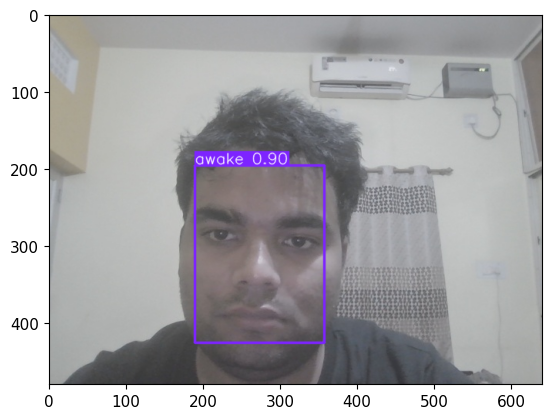

In [5]:
%matplotlib inline
plt.imshow(np.squeeze(results.render()))
plt.show()

Results

In [ ]:
cap = cv2.VideoCapture(0) # starts webcam and stores the data in cap variable
while cap.isOpened():
    ret,fram = cap.read()
    results =model(fram)
    cv2.imshow('Drowsiness Detection', np.squeeze(results.render()))

    if cv2.waitKey(10) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()